In [291]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [292]:
df = pd.read_csv("dirty_employee_salary_dataset.csv")  

In [293]:
df.head()

,Age,Experience,Education,JobRole,Location,Skills,CompanyType,Gender,Salary
0,36.0,15.0,Master,ML Engineer,Pune,AWS|SQL,Startup,NaN,2783653.0
1,41.0,5.0,PhD,UI/UX Designer,Pune,Python|SQL|React|CSS,Startup,Female,1560855.0
2,43.0,9.0,PhD,Data Analyst,Pune,HTML|CSS,MNC,Female,2320382.0
3,33.0,11.0,PhD,System Admin,Bangalore,HTML|Java,MNC,Male,2690016.0
4,21.0,0.0,PhD,AI Engineer,Delhi,SQL|ML,MNC,Male,1008032.0


In [294]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          993 non-null    float64
 1   Experience   999 non-null    float64
 2   Education    993 non-null    object 
 3   JobRole      1007 non-null   object 
 4   Location     1003 non-null   object 
 5   Skills       1000 non-null   object 
 6   CompanyType  1011 non-null   object 
 7   Gender       995 non-null    object 
 8   Salary       998 non-null    float64
dtypes: float64(3), object(6)
memory usage: 74.0+ KB


In [295]:
df.describe()

,Age,Experience,Salary
count,993.000000,999.000000,9.980000e+02
mean,36.876007,6.374771,1.617160e+06
std,15.183768,7.961358,1.267801e+06
min,21.000000,0.000000,1.821170e+05
25%,28.000000,1.000000,9.037680e+05
50%,35.000000,4.000000,1.314870e+06
75%,43.000000,9.000000,2.066922e+06
max,121.994036,51.066497,8.738394e+06


In [296]:
df.dtypes

Age            float64
Experience     float64
Education       object
JobRole         object
Location        object
Skills          object
CompanyType     object
Gender          object
Salary         float64
dtype: object

Handling missing values

In [297]:
df.isnull().sum()

Age            57
Experience     51
Education      57
JobRole        43
Location       47
Skills         50
CompanyType    39
Gender         55
Salary         52
dtype: int64

In [298]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Experience'] = df['Experience'].fillna(df['Experience'].mean())
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

In [299]:
cols = ['Education', 'JobRole', 'Location', 'Skills', 'CompanyType', 'Gender']

for col in cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [300]:
print(df.isnull().sum())

Age            0
Experience     0
Education      0
JobRole        0
Location       0
Skills         0
CompanyType    0
Gender         0
Salary         0
dtype: int64


Removing Duplicates

In [301]:
df.duplicated().sum()

np.int64(42)

In [302]:
df.drop_duplicates(inplace=True)

In [303]:
df.duplicated().sum()

np.int64(0)

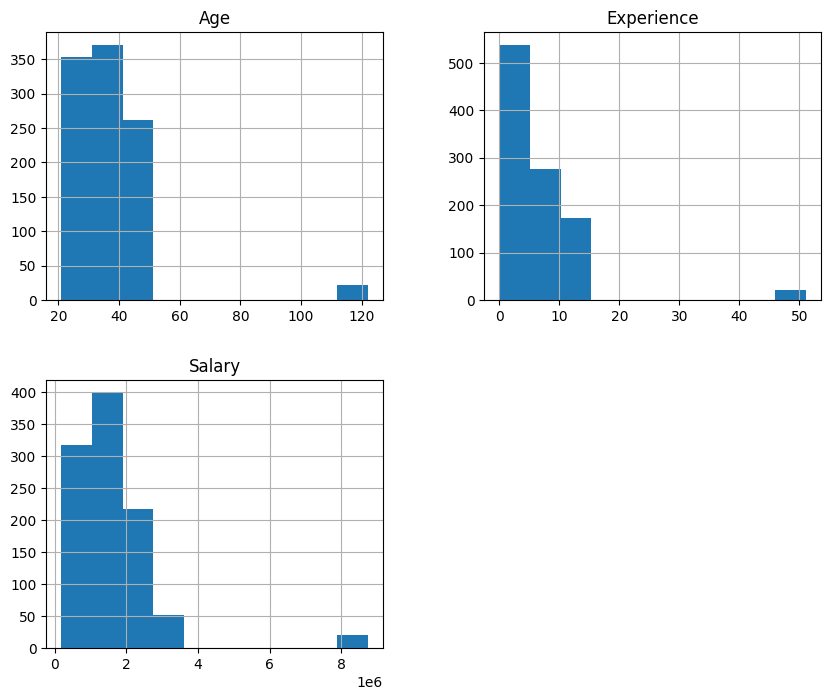

In [304]:
df.hist(figsize=(10,8))
plt.show()

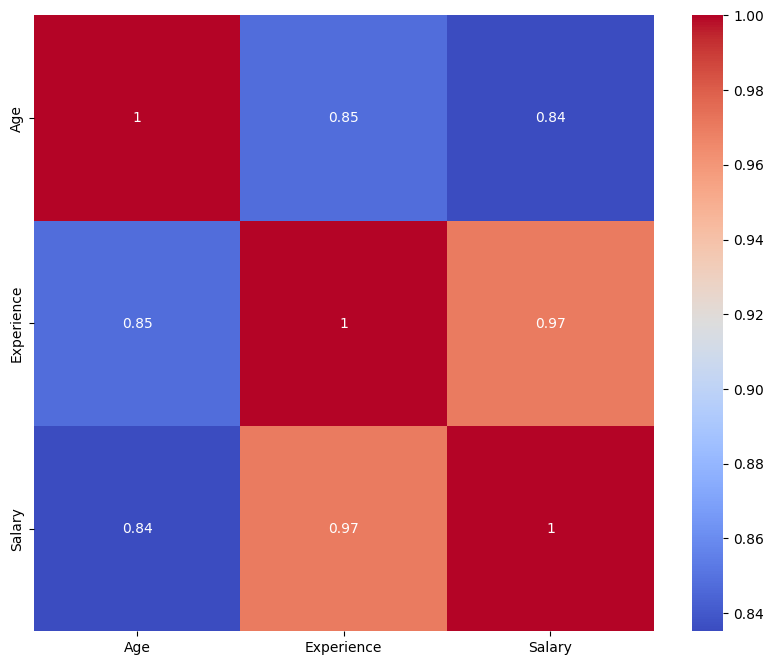

In [305]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

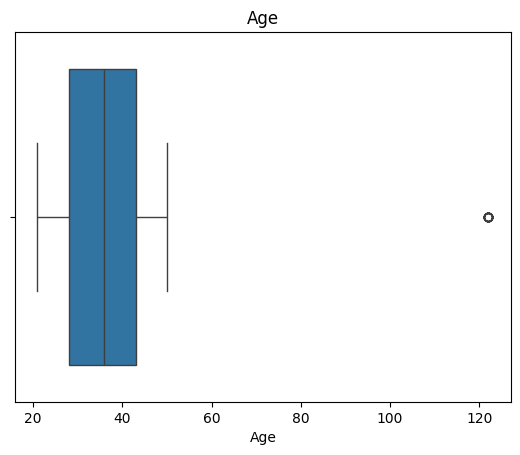

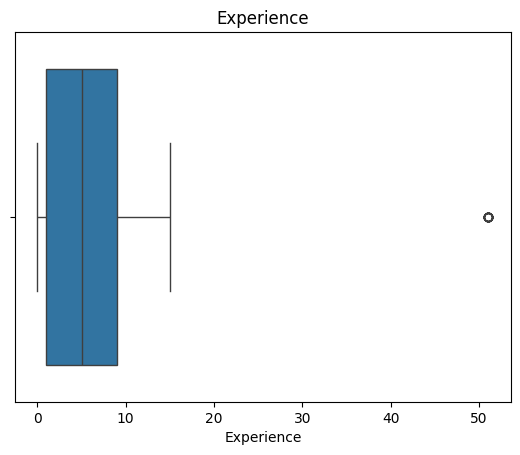

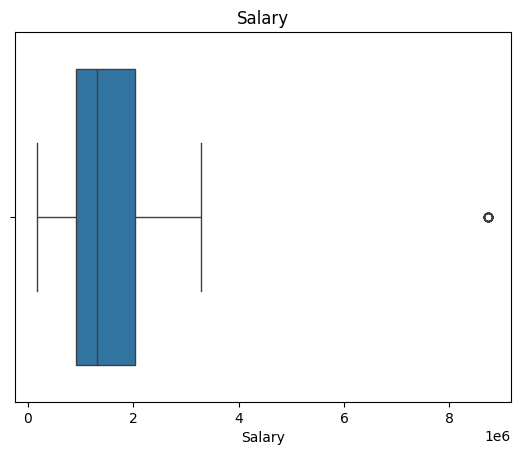

In [306]:
for col in df.select_dtypes(include=['int64','float64']).columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Removing the Outliers

In [307]:
num_cols = ['Age', 'Experience', 'Salary']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

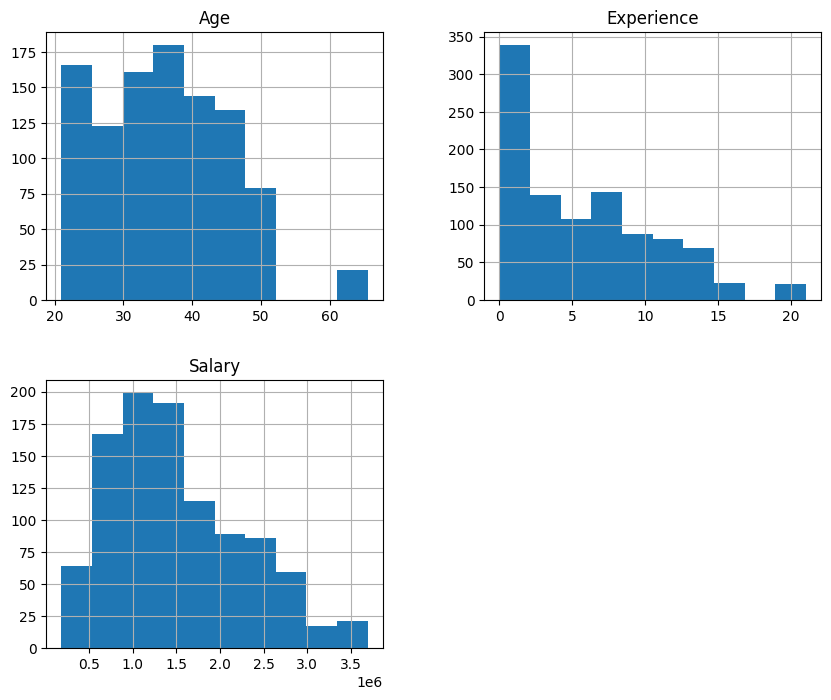

In [308]:
df.hist(figsize=(10,8))
plt.show()

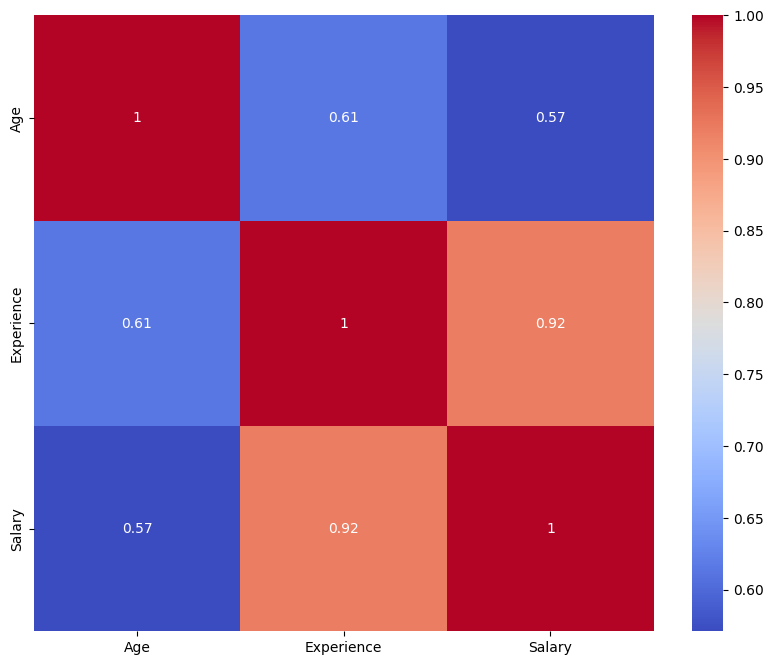

In [309]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

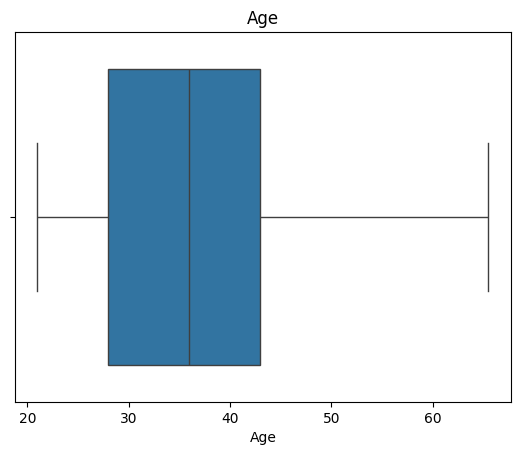

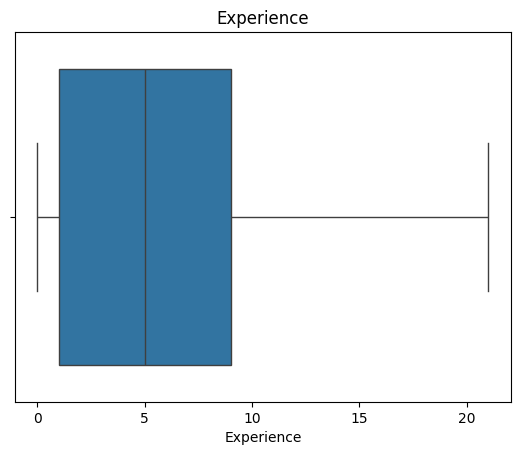

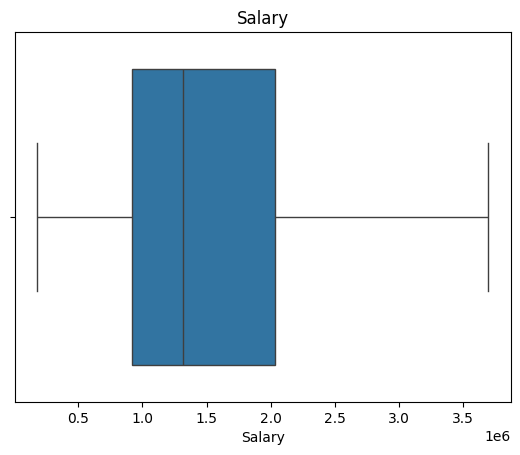

In [310]:
for col in df.select_dtypes(include=['int64','float64']).columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


In [311]:
df['skill_count'] = df['Skills'].apply(lambda x: len(str(x).split('|')))
df.drop('Skills', axis=1, inplace=True)

In [312]:
df.head()

,Age,Experience,Education,JobRole,Location,CompanyType,Gender,Salary,skill_count
0,36.0,15.0,Master,ML Engineer,Pune,Startup,Female,2783653.0,2
1,41.0,5.0,PhD,UI/UX Designer,Pune,Startup,Female,1560855.0,4
2,43.0,9.0,PhD,Data Analyst,Pune,MNC,Female,2320382.0,2
3,33.0,11.0,PhD,System Admin,Bangalore,MNC,Male,2690016.0,2
4,21.0,0.0,PhD,AI Engineer,Delhi,MNC,Male,1008032.0,2


In [313]:
def exp_level(x):
    if x < 2:
        return 'Fresher'
    elif x < 5:
        return 'Junior'
    elif x < 10:
        return 'Mid'
    else:
        return 'Senior'

df['exp_level'] = df['Experience'].apply(exp_level)

In [314]:
df.head()

,Age,Experience,Education,JobRole,Location,CompanyType,Gender,Salary,skill_count,exp_level
0,36.0,15.0,Master,ML Engineer,Pune,Startup,Female,2783653.0,2,Senior
1,41.0,5.0,PhD,UI/UX Designer,Pune,Startup,Female,1560855.0,4,Mid
2,43.0,9.0,PhD,Data Analyst,Pune,MNC,Female,2320382.0,2,Mid
3,33.0,11.0,PhD,System Admin,Bangalore,MNC,Male,2690016.0,2,Senior
4,21.0,0.0,PhD,AI Engineer,Delhi,MNC,Male,1008032.0,2,Fresher


In [315]:
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index(['Education', 'JobRole', 'Location', 'CompanyType', 'Gender',
       'exp_level'],
      dtype='object')


In [316]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [317]:
df.head()

,Age,Experience,Salary,skill_count,Education_Bachelor,Education_MASTER,Education_Master,Education_NAN,Education_PHD,Education_PhD,...,CompanyType_NAN,CompanyType_STARTUP,CompanyType_Startup,Gender_Female,Gender_MALE,Gender_Male,Gender_NAN,exp_level_Junior,exp_level_Mid,exp_level_Senior
0,36.0,15.0,2783653.0,2,False,False,True,False,False,False,...,False,False,True,True,False,False,False,False,False,True
1,41.0,5.0,1560855.0,4,False,False,False,False,False,True,...,False,False,True,True,False,False,False,False,True,False
2,43.0,9.0,2320382.0,2,False,False,False,False,False,True,...,False,False,False,True,False,False,False,False,True,False
3,33.0,11.0,2690016.0,2,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,True
4,21.0,0.0,1008032.0,2,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False


In [318]:
df = df.astype(int)

In [319]:
df.head()

,Age,Experience,Salary,skill_count,Education_Bachelor,Education_MASTER,Education_Master,Education_NAN,Education_PHD,Education_PhD,...,CompanyType_NAN,CompanyType_STARTUP,CompanyType_Startup,Gender_Female,Gender_MALE,Gender_Male,Gender_NAN,exp_level_Junior,exp_level_Mid,exp_level_Senior
0,36,15,2783653,2,0,0,1,0,0,0,...,0,0,1,1,0,0,0,0,0,1
1,41,5,1560855,4,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,1,0
2,43,9,2320382,2,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0
3,33,11,2690016,2,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
4,21,0,1008032,2,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0


In [320]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


df[['Age', 'Experience']] = scaler.fit_transform(df[['Age', 'Experience']])

In [321]:
df[['Age']].head()

,Age
0,0.340909
1,0.454545
2,0.500000
3,0.272727
4,0.000000


In [322]:
df[['Experience']].head()

,Experience
0,0.714286
1,0.238095
2,0.428571
3,0.523810
4,0.000000


In [323]:
df.head()

,Age,Experience,Salary,skill_count,Education_Bachelor,Education_MASTER,Education_Master,Education_NAN,Education_PHD,Education_PhD,...,CompanyType_NAN,CompanyType_STARTUP,CompanyType_Startup,Gender_Female,Gender_MALE,Gender_Male,Gender_NAN,exp_level_Junior,exp_level_Mid,exp_level_Senior
0,0.340909,0.714286,2783653,2,0,0,1,0,0,0,...,0,0,1,1,0,0,0,0,0,1
1,0.454545,0.238095,1560855,4,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,1,0
2,0.500000,0.428571,2320382,2,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0
3,0.272727,0.523810,2690016,2,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
4,0.000000,0.000000,1008032,2,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0


In [324]:
df.dtypes

Age                   float64
Experience            float64
Salary                  int64
skill_count             int64
Education_Bachelor      int64
                       ...   
Gender_Male             int64
Gender_NAN              int64
exp_level_Junior        int64
exp_level_Mid           int64
exp_level_Senior        int64
Length: 70, dtype: object